In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

**Reading the file**

In [31]:
df = pd.read_csv('data/ai_job_market.csv')
print(df.head())


   job_id                  job_title company_size company_industry    country  \
0       1                AI Engineer      Startup           Retail     Canada   
1       2  Machine Learning Engineer          MNC       Technology  Australia   
2       3  Machine Learning Engineer          MNC       Technology    Germany   
3       4           Business Analyst      Startup       Healthcare    Germany   
4       5             Data Scientist          MNC       Healthcare    Germany   

  remote_type experience_level  years_experience education_level  \
0      Remote           Senior                 2          Master   
1      Hybrid              Mid                 0        Bachelor   
2      Onsite              Mid                14          Master   
3      Remote              Mid                 9          Master   
4      Hybrid              Mid                 5          Master   

   skills_python  skills_sql  skills_ml  skills_deep_learning  skills_cloud  \
0              0         

In [32]:
df.columns

Index(['job_id', 'job_title', 'company_size', 'company_industry', 'country',
       'remote_type', 'experience_level', 'years_experience',
       'education_level', 'skills_python', 'skills_sql', 'skills_ml',
       'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month',
       'job_posting_year', 'hiring_urgency', 'job_openings'],
      dtype='str')

**cleaning the data**

In [53]:
df=df.drop('job_id',axis=1)
df


,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10340,Data Engineer,Startup,Technology,USA,Onsite,Entry,2,PhD,1,0,1,0,1,76426,4,2023,Low,4
10341,Data Analyst,Medium,Healthcare,Australia,Hybrid,Entry,10,Master,1,1,0,0,1,61233,9,2024,Medium,6
10342,Machine Learning Engineer,Startup,Education,Germany,Hybrid,Entry,4,PhD,0,0,0,1,0,103681,3,2026,Low,4
10343,Data Engineer,MNC,E-commerce,Canada,Hybrid,Mid,5,PhD,1,1,1,0,0,112895,12,2024,High,9


**Shape of the data**

In [33]:
df.shape

(10345, 19)

In [34]:
df.isna().sum()

job_id                  0
job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64

**As we can observe there is no null values in any features in the given dataset**

In [35]:
df.duplicated().sum()

np.int64(0)

**Not a single duplicate datas in the dataset**

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_id                10345 non-null  int64
 1   job_title             10345 non-null  str  
 2   company_size          10345 non-null  str  
 3   company_industry      10345 non-null  str  
 4   country               10345 non-null  str  
 5   remote_type           10345 non-null  str  
 6   experience_level      10345 non-null  str  
 7   years_experience      10345 non-null  int64
 8   education_level       10345 non-null  str  
 9   skills_python         10345 non-null  int64
 10  skills_sql            10345 non-null  int64
 11  skills_ml             10345 non-null  int64
 12  skills_deep_learning  10345 non-null  int64
 13  skills_cloud          10345 non-null  int64
 14  salary                10345 non-null  int64
 15  job_posting_month     10345 non-null  int64
 16  job_posting_yea

**checking the number of unique datas in each features**

In [37]:
df.nunique()

job_id                  10345
job_title                   6
company_size                4
company_industry            6
country                     7
remote_type                 3
experience_level            3
years_experience           15
education_level             3
skills_python               2
skills_sql                  2
skills_ml                   2
skills_deep_learning        2
skills_cloud                2
salary                   9901
job_posting_month          12
job_posting_year            7
hiring_urgency              3
job_openings                9
dtype: int64

**Studying the statistice of the features**

In [38]:
df.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


In [55]:
categorical_features = [feature for feature in df.columns if df[feature].dtype!=int]
numerical_features = [feature for feature in df.columns if df[feature].dtype==int]
print(f'The categorical features are: {categorical_features}')
print(f'The numerical features are: {numerical_features}')

The categorical features are: ['job_title', 'company_size', 'company_industry', 'country', 'remote_type', 'experience_level', 'education_level', 'hiring_urgency']
The numerical features are: ['years_experience', 'skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month', 'job_posting_year', 'job_openings']


**visualizing the salary based on different categorical features**

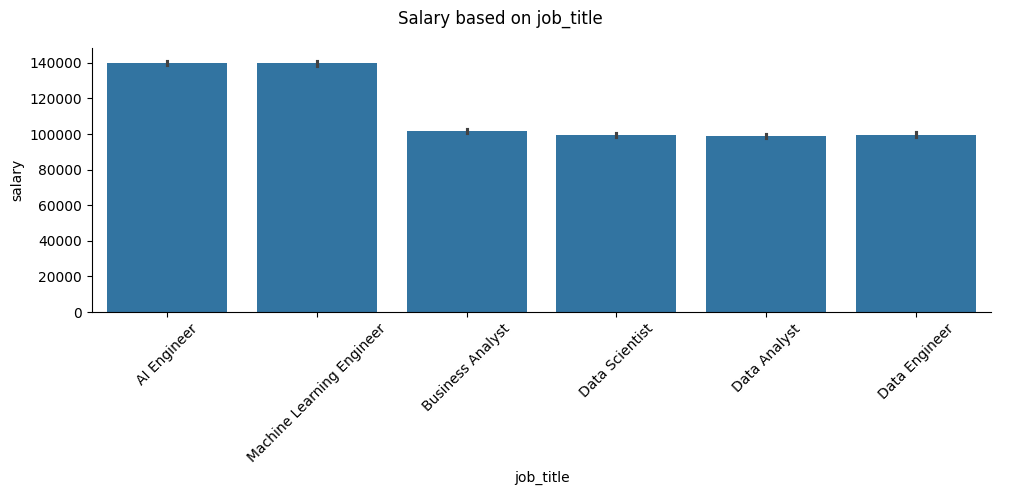

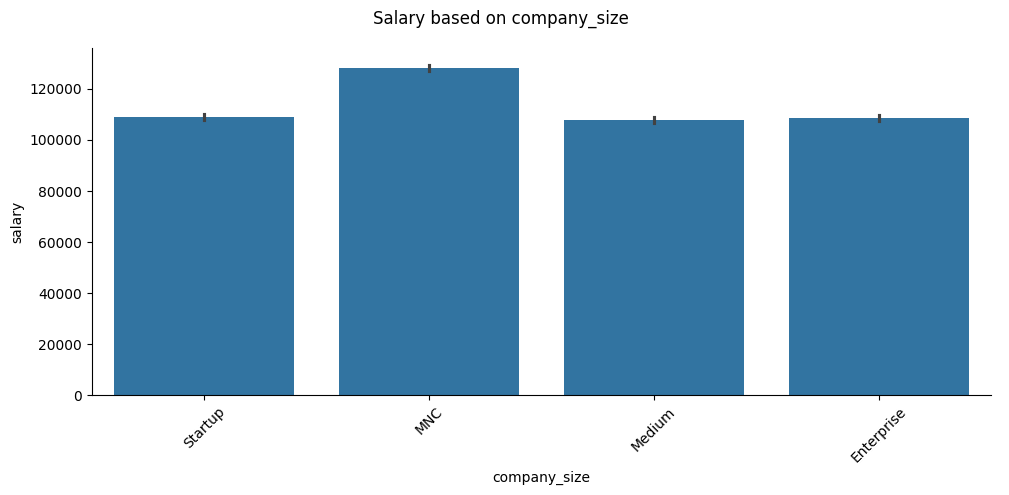

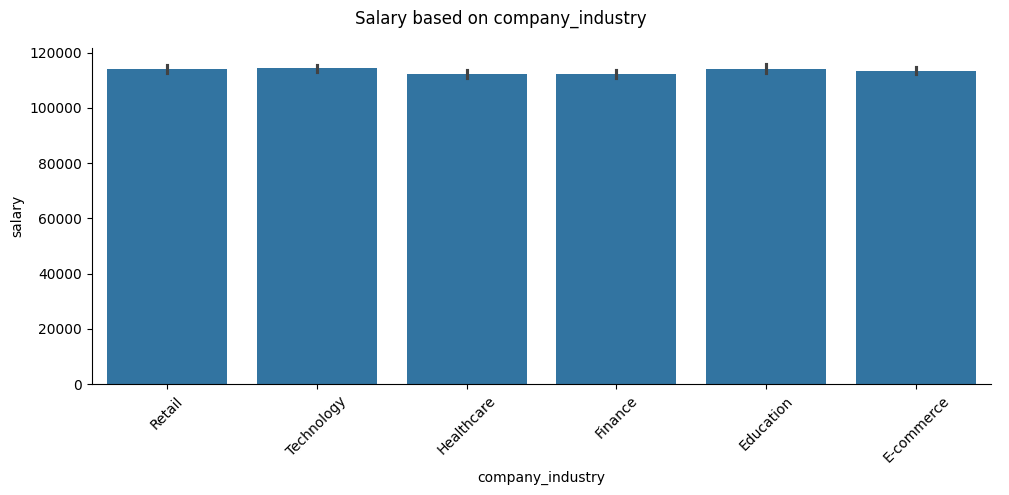

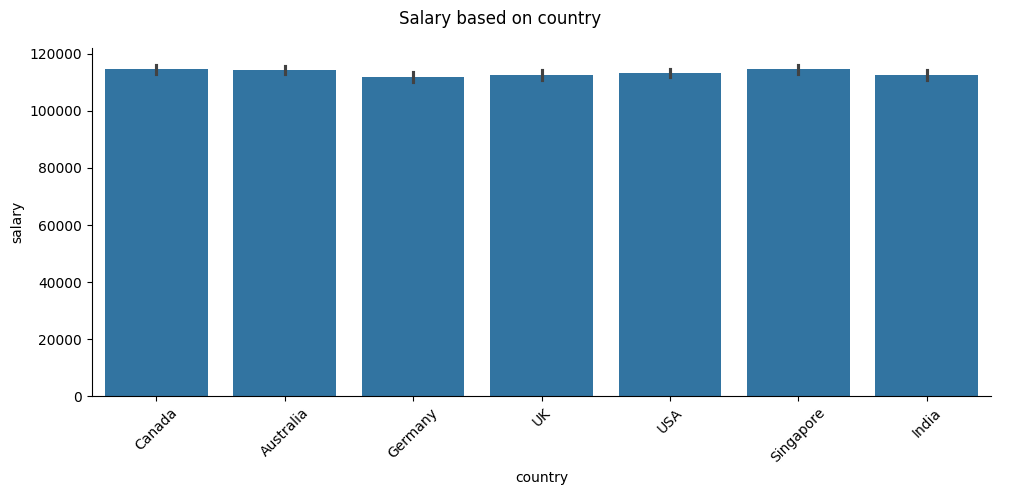

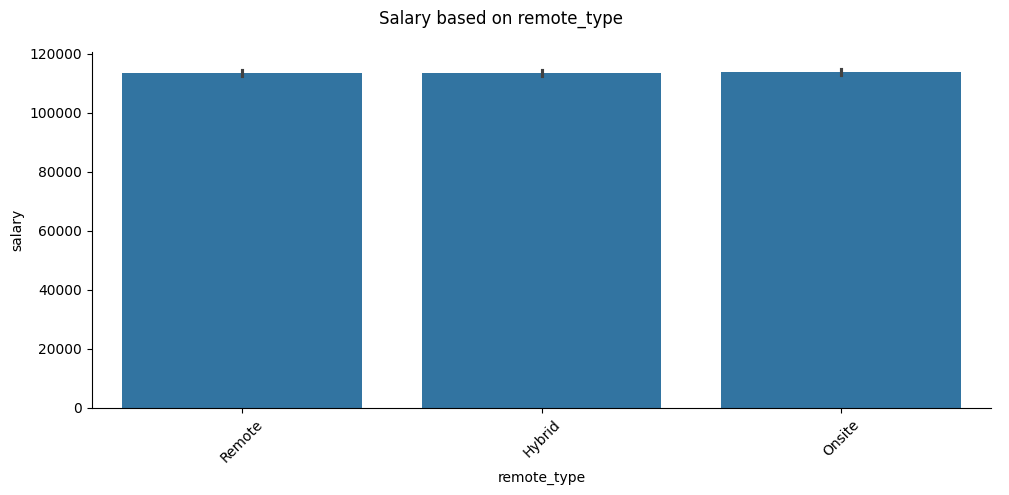

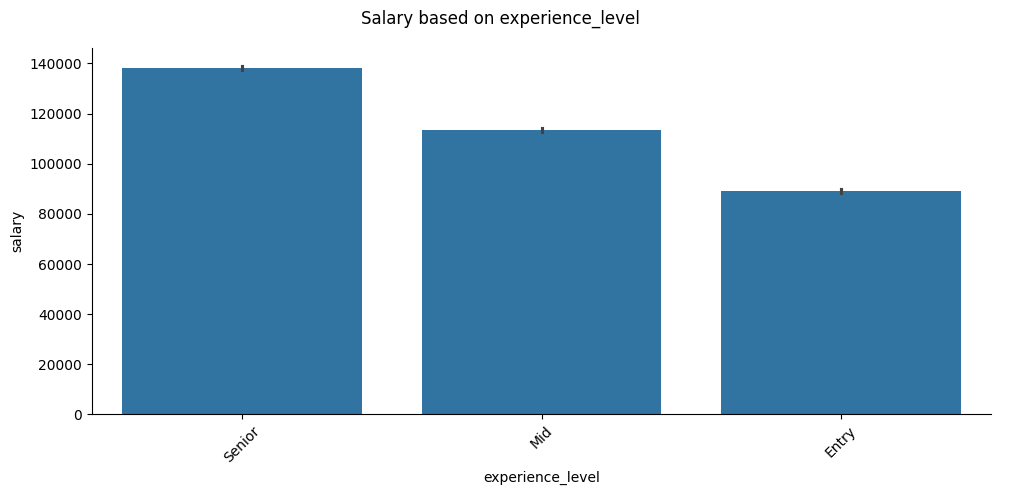

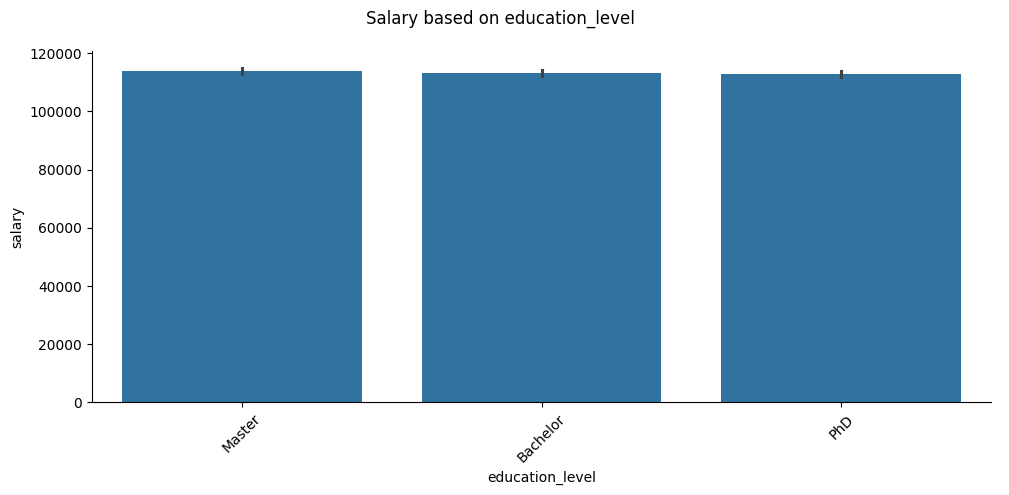

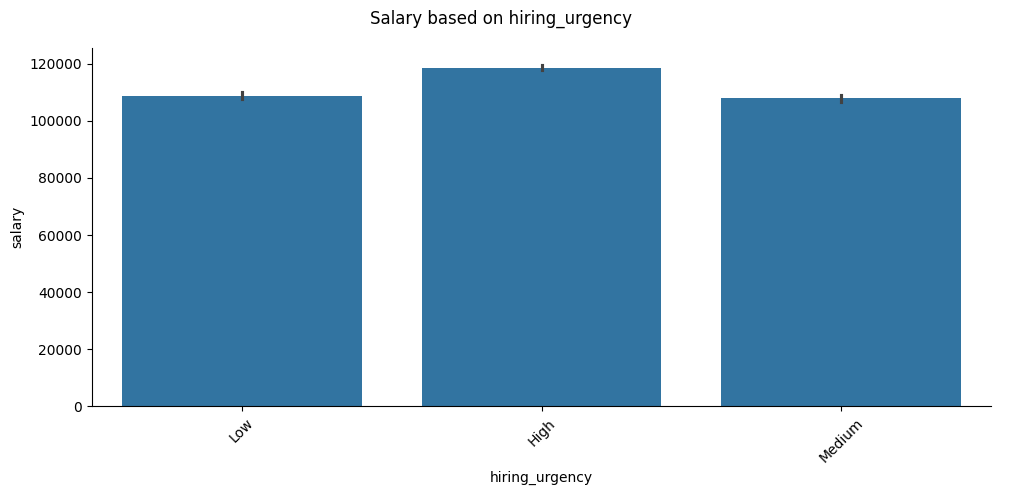

In [61]:
for feature in categorical_features: 
    g = sns.catplot(
        x=feature,
        y='salary',
        data=df,
        kind='bar',
        height=5,
        aspect=2
    )
    g.set_xticklabels(rotation=45)
    g.fig.suptitle(f'Salary based on {feature}')
    plt.tight_layout()
    plt.show()

**visualizing the salary based on different numerical features**

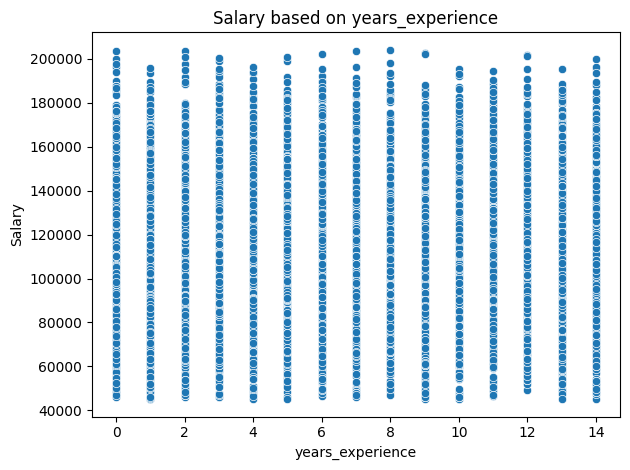

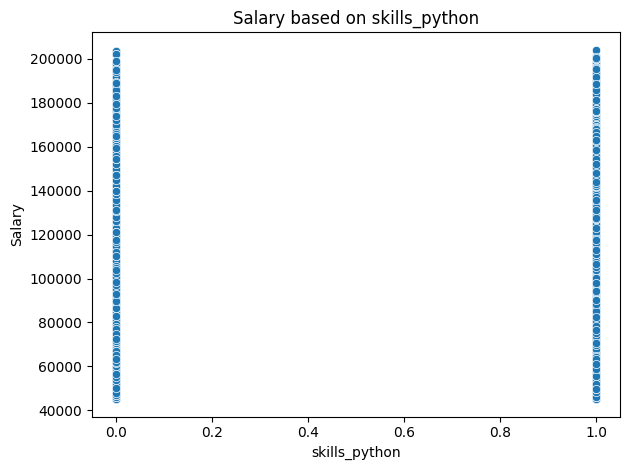

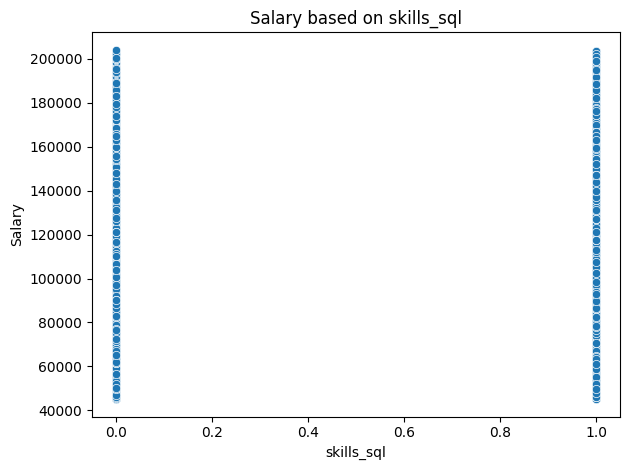

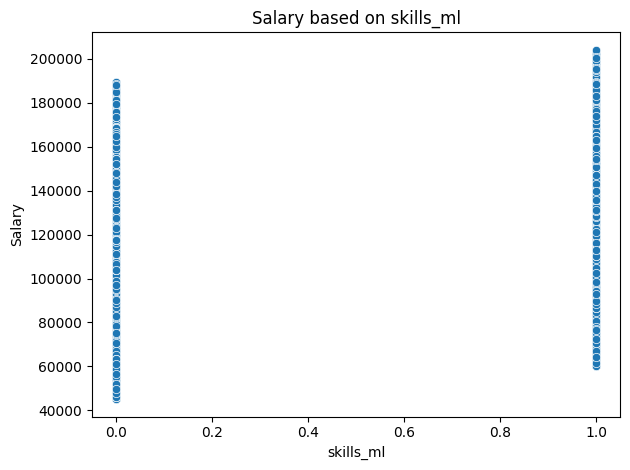

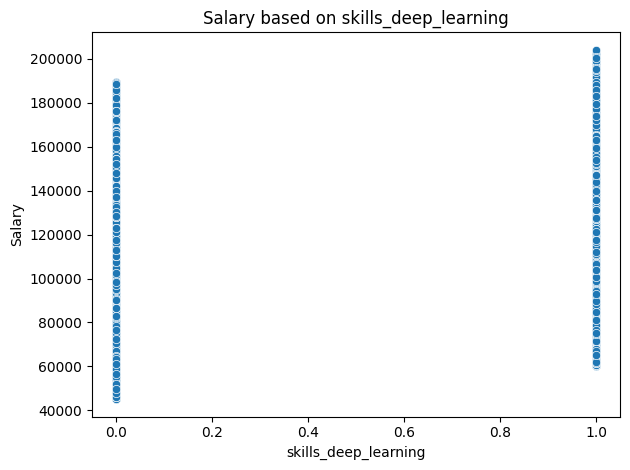

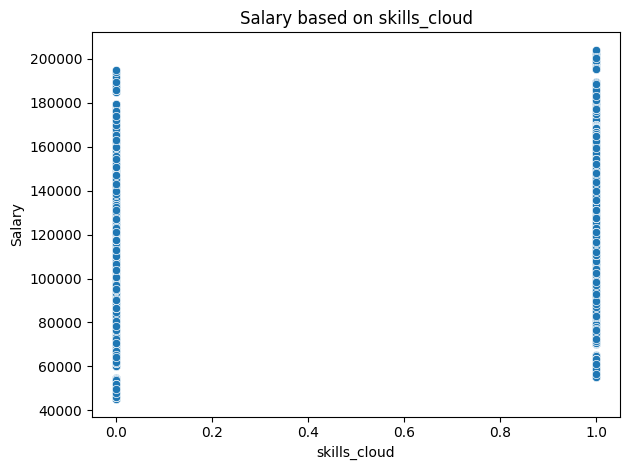

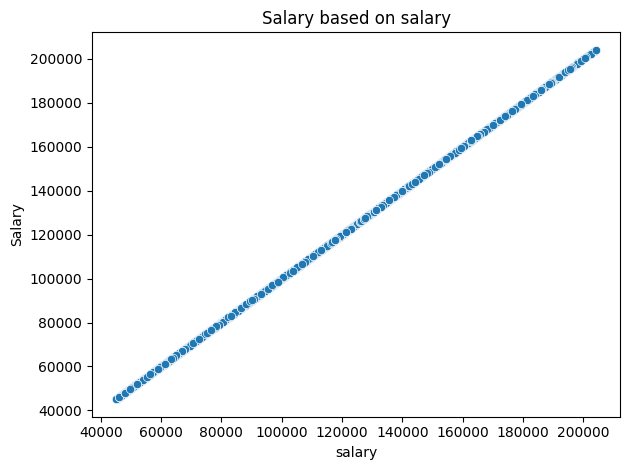

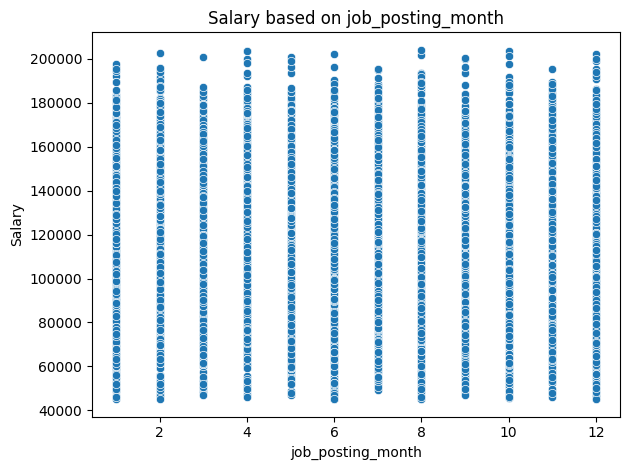

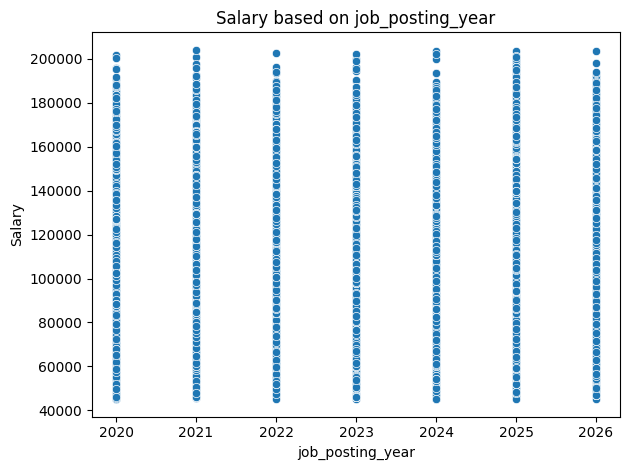

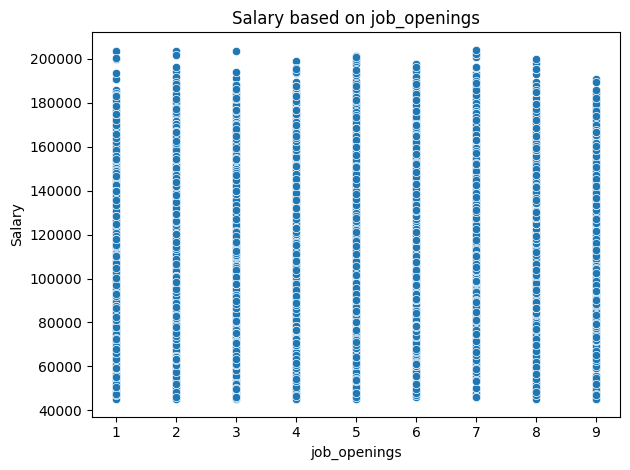

In [69]:
for feature in numerical_features: 
    sns.scatterplot(x=feature,y ='salary',data=df)
    plt.xlabel(feature)
    plt.ylabel('Salary')
    plt.title(f'Salary based on {feature}')
    plt.tight_layout()
    plt.show()

**Checking the correlation between salary and other numerical variables**

In [63]:
corr = df[numerical_features].corr()['salary'].drop('salary').sort_values(ascending=False)
corr

skills_deep_learning    0.242504
skills_ml               0.232621
skills_cloud            0.153725
skills_python           0.009536
job_openings            0.005715
job_posting_year        0.003028
skills_sql             -0.003473
years_experience       -0.013266
job_posting_month      -0.013555
Name: salary, dtype: float64

**Plotting the correlation between salary and numeric features**

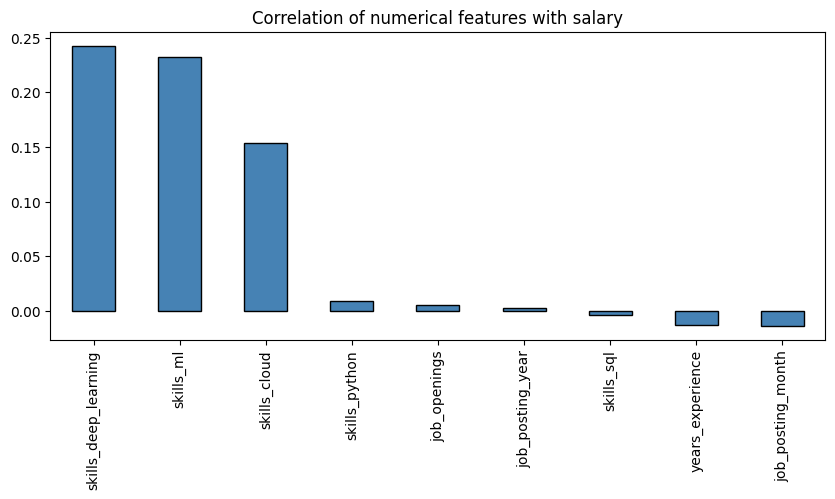

In [68]:
corr.plot(kind='bar',figsize=(10, 4), color='steelblue', edgecolor='black')
plt.title('Correlation of numerical features with salary')
plt.show()